# Convolutional Autoencoder — Starter Notebook (PyTorch) -- Problem Set 3, Task 4

This notebook trains a **convolutional autoencoder (CAE)** with a **4-dimensional latent space** on a small subset of 100 barred-spiral galaxy images (64 × 64 pixels, grayscale) from the Galaxy10 DECals catalogue.

It is intended as a working template for **Problem Set 3, Task 4**.  
Once you have this running, adapt it to:
- the full down-sampled grayscale dataset (all 17 736 images, all classes)
- the latent-space analysis tasks (Tasks 5 & 6)

**Runtime on CPU:** ≈ 2–4 minutes for 200 epochs on a modern laptop.
**Runtime on GPU:** ≈ a few seconds for 200 epochs.

Use e.g. [Google Colab](https://colab.research.google.com/) if you don't have a GPU available locally.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# reproducibility
torch.manual_seed(0)
np.random.seed(0)

# use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: mps


## 2. Load the image subset

The file `galaxy10_barred_spiral_64x64_100.npy` contains 100 randomly selected barred-spiral galaxies (class 5) from Galaxy10 DECals, pre-processed to:
- grayscale (average of g, r, z bands)
- 4× block-average downsampled: 256 × 256 → **64 × 64**
- pixel values normalised to **[0, 1]**

Shape: `(100, 64, 64)`, dtype `float32`.

In [2]:
images = np.load('galaxy10_barred_spiral_64x64_100.npy')   # (100, 64, 64)
print('Loaded:', images.shape, '  dtype:', images.dtype)
print('Pixel range: [{:.3f}, {:.3f}]'.format(images.min(), images.max()))

Loaded: (100, 64, 64)   dtype: float32
Pixel range: [0.065, 0.999]


### 2.1 Visualise a few galaxies

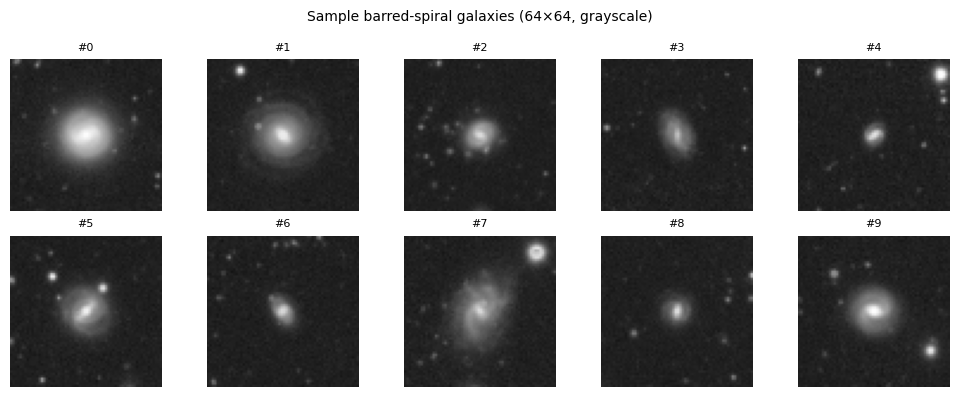

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f'#{i}', fontsize=8)
plt.suptitle('Sample barred-spiral galaxies (64×64, grayscale)', fontsize=10)
plt.tight_layout()
plt.show()

### 2.2 Train / validation split and DataLoader

We use 80 images for training and 20 for validation.

PyTorch convolutions expect **channel-first** tensors: shape `(N, C, H, W)`.  
We add a singleton channel dimension with `[:, None, :, :]`.

In [4]:
N_TRAIN    = 80
BATCH_SIZE = 16

# add channel dim: (N, 1, 64, 64)
x_train = torch.tensor(images[:N_TRAIN,  None, :, :], dtype=torch.float32)
x_val   = torch.tensor(images[N_TRAIN:,  None, :, :], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train, x_train),   # input == target (autoencoder)
    batch_size=BATCH_SIZE, shuffle=True
)

print(f'Training images:   {x_train.shape}')
print(f'Validation images: {x_val.shape}')

Training images:   torch.Size([80, 1, 64, 64])
Validation images: torch.Size([20, 1, 64, 64])


## 3. Define the convolutional autoencoder

The architecture mirrors the one from the lecture notes:

| Stage | Layer | Output shape |
|---|---|---|
| Encoder | Conv2d(1→32, 3×3, stride 2) + ReLU | 32×32×32 |
| | Conv2d(32→64, 3×3, stride 2) + ReLU | 16×16×64 |
| | Conv2d(64→128, 3×3, stride 2) + ReLU | 8×8×128 |
| | Flatten + Linear → **latent** | 4 |
| Decoder | Linear → Reshape | 8×8×128 |
| | ConvTranspose2d(128→128, stride 2) + ReLU | 16×16×128 |
| | ConvTranspose2d(128→64, stride 2) + ReLU | 32×32×64 |
| | ConvTranspose2d(64→32, stride 2) + ReLU | 64×64×32 |
| | Conv2d(32→1, 3×3) + Sigmoid | 64×64×1 |

In [5]:
class ConvAutoencoder(nn.Module):
    """Convolutional autoencoder for square single-channel images."""

    def __init__(self, channels: int, size: int, latent_dim: int = 4):
        """
        Parameters
        ----------
        channels  : number of input channels (1 for grayscale)
        size      : spatial size of the input image (must be divisible by 8)
        latent_dim: dimension of the bottleneck (latent space)
        """
        super().__init__()
        assert size % 8 == 0, 'image size must be divisible by 8'
        self.latent_dim = latent_dim
        s = size // 8          # spatial size after 3 stride-2 convolutions
        self.s = s
        flat = 128 * s * s     # number of features before the bottleneck Dense

        # --- Encoder ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(channels, 32,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,       64,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,       128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.enc_fc = nn.Linear(flat, latent_dim)

        # --- Decoder ---
        self.dec_fc = nn.Linear(latent_dim, flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128,  64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d( 64,  32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(32, channels, 3, stride=1, padding=1),
            nn.Sigmoid(),   # output in [0, 1] to match normalised pixel values
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Map an image batch to latent vectors."""
        h = self.enc_conv(x)                      # (N, 128, s, s)
        h = h.view(h.size(0), -1)                 # (N, 128*s*s)  flatten
        return self.enc_fc(h)                      # (N, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Map latent vectors back to images."""
        h = self.dec_fc(z)                         # (N, 128*s*s)
        h = h.view(h.size(0), 128, self.s, self.s) # (N, 128, s, s)  reshape
        return self.dec_conv(h)                    # (N, channels, H, W)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))

In [6]:
LATENT_DIM = 4
SIZE       = 64
CHANNELS   = 1

model = ConvAutoencoder(channels=CHANNELS, size=SIZE, latent_dim=LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
print(model)

Total trainable parameters: 406,533
ConvAutoencoder(
  (enc_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=8192, out_features=4, bias=True)
  (dec_fc): Linear(in_features=4, out_features=8192, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)


## 4. Training

We minimise the mean squared error (MSE) between input and reconstruction:
$$
\mathcal{L} = \frac{1}{N}\sum_{i=1}^N \|\hat{\mathbf{x}}_i - \mathbf{x}_i\|^2.
$$

**Data augmentation:** because the training set is small (80 images), we randomly flip images horizontally and vertically during training.  This effectively multiplies the variety of examples seen per epoch and reduces overfitting.

In [7]:
EPOCHS = 200

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

x_val_dev = x_val.to(device)

train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # --- training ---
    model.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        # data augmentation: random horizontal / vertical flip of image to increase training data set
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[3])   # horizontal flip
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[2])   # vertical flip

        optimizer.zero_grad()
        loss = loss_fn(model(x_batch), x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= N_TRAIN
    train_losses.append(epoch_loss)

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(x_val_dev), x_val_dev).item()
    val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train loss: {epoch_loss:.5f}  val loss: {val_loss:.5f}')

print('Training complete.')

Epoch  20/200  train loss: 0.00462  val loss: 0.00846
Epoch  40/200  train loss: 0.00425  val loss: 0.00885
Epoch  60/200  train loss: 0.00322  val loss: 0.00639
Epoch  80/200  train loss: 0.00221  val loss: 0.00529
Epoch 100/200  train loss: 0.00213  val loss: 0.00633
Epoch 120/200  train loss: 0.00207  val loss: 0.00685
Epoch 140/200  train loss: 0.00197  val loss: 0.00831
Epoch 160/200  train loss: 0.00195  val loss: 0.00837
Epoch 180/200  train loss: 0.00191  val loss: 0.00935
Epoch 200/200  train loss: 0.00191  val loss: 0.01049
Training complete.


## 5. Training curve
The training curve in this case shows a clear sign of overfitting: the training loss continues to decrease, while the validation loss starts to increase after ≈ 50 epochs. The reason is that the model has too much capacity (too many parameters) relative to the small training set, and it starts to memorise the training examples instead of learning general features.

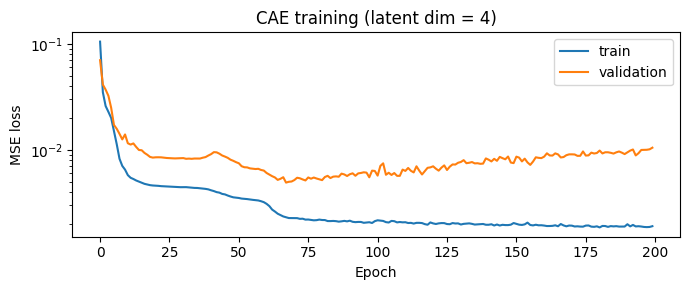

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title(f'CAE training (latent dim = {LATENT_DIM})')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 6. Reconstruction quality

Each column shows one validation galaxy.  
**Top row:** original image.  **Bottom row:** reconstruction from the 4-dimensional latent code.

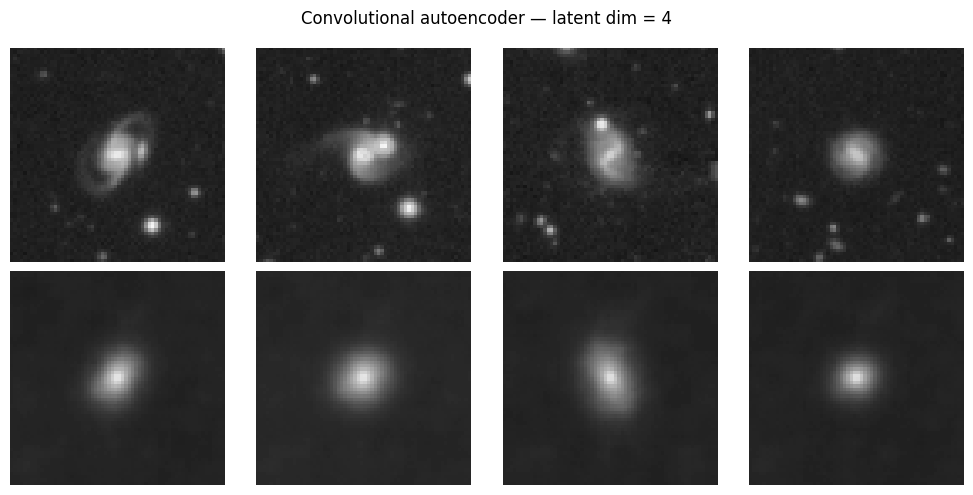

In [9]:
N_SHOW = 4

model.eval()
with torch.no_grad():
    recons = model(x_val_dev[:N_SHOW]).cpu().numpy()   # (N_SHOW, 1, 64, 64)

originals = x_val[:N_SHOW].numpy()                     # (N_SHOW, 1, 64, 64)

fig, axes = plt.subplots(2, N_SHOW, figsize=(2.5 * N_SHOW, 5))

row_labels = ['Original', 'Reconstruction']
for row, (imgs, label) in enumerate(zip([originals, recons], row_labels)):
    axes[row, 0].set_ylabel(label, fontsize=11)
    for col in range(N_SHOW):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

plt.suptitle(f'Convolutional autoencoder — latent dim = {LATENT_DIM}', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Inspect the latent codes

Let's look at what the encoder produces for the validation set — the raw 4-dimensional latent vectors.

In [10]:
model.eval()
with torch.no_grad():
    z_val = model.encode(x_val_dev).cpu().numpy()   # (20, 4)

print('Latent vectors shape:', z_val.shape)
print('\nPer-dimension statistics:')
print(f'  {"dim":>3}  {"mean":>8}  {"std":>8}  {"min":>8}  {"max":>8}')
for i in range(LATENT_DIM):
    print(f'  {i:>3}  {z_val[:,i].mean():>8.3f}  {z_val[:,i].std():>8.3f}'
          f'  {z_val[:,i].min():>8.3f}  {z_val[:,i].max():>8.3f}')

Latent vectors shape: (20, 4)

Per-dimension statistics:
  dim      mean       std       min       max
    0     5.036     1.979     2.554     9.405
    1    -2.152     1.704    -7.699     1.975
    2    -2.027     3.866    -6.151     9.664
    3     0.415     4.777    -9.218     4.323
